# PHÂN TÍCH CHẤT LƯỢNG CÂU HỎI CỦA CÁC ĐỀ THI CHUẨN HOÁ VÀ ĐÁNH GIÁ NĂNG LỰC THÍ SINH

In [177]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so
import irt
import ctt
import item_plot as ip

In [178]:
df_dot1 = pd.read_csv("lan1.csv")
df_dot2 = pd.read_csv("lan2.csv")
da_1 = pd.read_csv("ans_1.csv", delimiter=";")
da_2 = pd.read_csv("ans_2.csv", delimiter=";")

df_dot1.drop_duplicates(subset=['Email'], keep='last', inplace=True)
df_dot2.drop_duplicates(subset=['Email'], keep='last', inplace=True)

In [179]:
df_dot1, df_dot2, da_1, da_2

(        SBD                     Timestamp  \
 0    110001   2025/10/19 4:46:46 PM GMT+7   
 1    110002   2025/10/18 1:05:06 PM GMT+7   
 2    110003  2025/10/19 12:42:42 PM GMT+7   
 3    110004   2025/10/19 5:48:44 PM GMT+7   
 4    110005   2025/10/18 1:25:28 PM GMT+7   
 ..      ...                           ...   
 471  110472   2025/10/11 3:07:53 PM GMT+7   
 472  110473  2025/10/19 12:00:37 AM GMT+7   
 473  110474   2025/10/03 9:24:46 PM GMT+7   
 474  110475  2025/10/18 10:14:54 PM GMT+7   
 475  110476                           NaN   
 
                                    Email                   Name Gioi  MaDe  \
 0             07vudinhchien8a2@gmail.com          Vũ Đình Chiến  Nam   107   
 1                    09022008a@gmail.com                 beaver   Nữ   107   
 2    19.nguyenminhtuankiet.9.1@gmail.com  Nguyễn Minh Tuấn Kiệt  Nam   107   
 3      2008.lvklinh.nguyenhien@gmail.com              kling_296   Nữ   107   
 4                2008trankhanh@gmail.com        Tr

In [180]:
# Tổng số thí sinh thi mỗi đề
print(f'Tổng số thí sinh thi đề 1: {df_dot1.shape[0]}')
print(f'Tổng số thí sinh thi đề 2: {df_dot2.shape[0]}')

Tổng số thí sinh thi đề 1: 469
Tổng số thí sinh thi đề 2: 752


In [181]:
thisinh_1 = pd.Series(df_dot1['Email'])
thisinh_2 = pd.Series(df_dot2['Email'])

# cho biết có bao nhiêu thí sinh nào thi cả 2 đề hay chỉ thi 1 trong 2 đề
thisinh_both = pd.Series(list(set(thisinh_1) & set(thisinh_2)))
thisinh_only1 = pd.Series(list(set(thisinh_1) - set(thisinh_2)))
thisinh_only2 = pd.Series(list(set(thisinh_2) - set(thisinh_1)))
print('--- Thống kê thí sinh có tham gia thi 2 đề ---')
print(f'Số thí sinh thi cả 2 đề: {thisinh_both.shape[0]}')
print(f'Số thí sinh chỉ thi đề 1: {thisinh_only1.shape[0]}')
print(f'Số thí sinh chỉ thi đề 2: {thisinh_only2.shape[0]}')

--- Thống kê thí sinh có tham gia thi 2 đề ---
Số thí sinh thi cả 2 đề: 241
Số thí sinh chỉ thi đề 1: 228
Số thí sinh chỉ thi đề 2: 511


In [182]:
gioi= pd.DataFrame(
    {'Đề 1': df_dot1['Gioi'],
    'Đề 2': df_dot2['Gioi']}
)

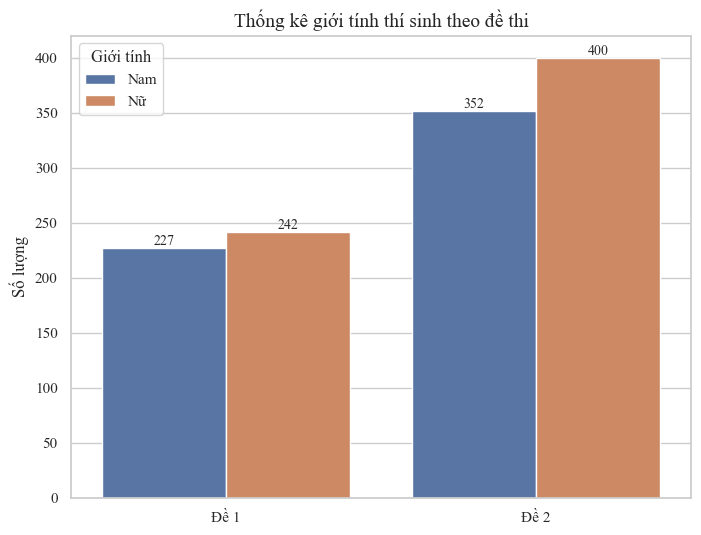

In [183]:
sns.set_style("whitegrid")
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] 
plt.figure(figsize=(8, 6))
sns.countplot(data=gioi.melt(var_name='Đề', value_name='Giới tính'), x='Đề', hue='Giới tính')
plt.title('Thống kê giới tính thí sinh theo đề thi', fontsize=14)
plt.xlabel(None)
plt.ylabel('Số lượng')
#thêm nhãn trên mỗi cột
for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10)


In [184]:
# lập thành bảng thống kê
gioi_counts = gioi.apply(pd.Series.value_counts).astype(int)
gioi_counts

,Đề 1,Đề 2
Nữ,242,400
Nam,227,352


In [185]:
df_chamdiem_1 = ip.ketQuaCham(df_dot1, da_1)
df_chamdiem_2 = ip.ketQuaCham(df_dot2, da_2)

In [186]:
order_kho = ['Rất dễ', 'Dễ', 'Tương đối dễ', 'Bình thường', 'Tương đối khó', 'Khó','Rất khó']
order_pb  = ['Kém', 'Chưa tốt', 'Chấp nhận được', 'Tương đối tốt', 'Tốt', 'Rất tốt','Quá tốt']
order_nhieu = ["Kém", "Yếu", "Bình thường", "Tốt"]

In [187]:
df_TV1, df_TA1, df_TO1, df_KH1 = ip.tach_phan(df_chamdiem_1)
df_TV2, df_TA2, df_TO2, df_KH2 = ip.tach_phan(df_chamdiem_2)

for data in [df_TV1, df_TA1, df_TO1, df_KH1, df_TV2, df_TA2, df_TO2, df_KH2]:
    data = ip.tinh_diem(data)

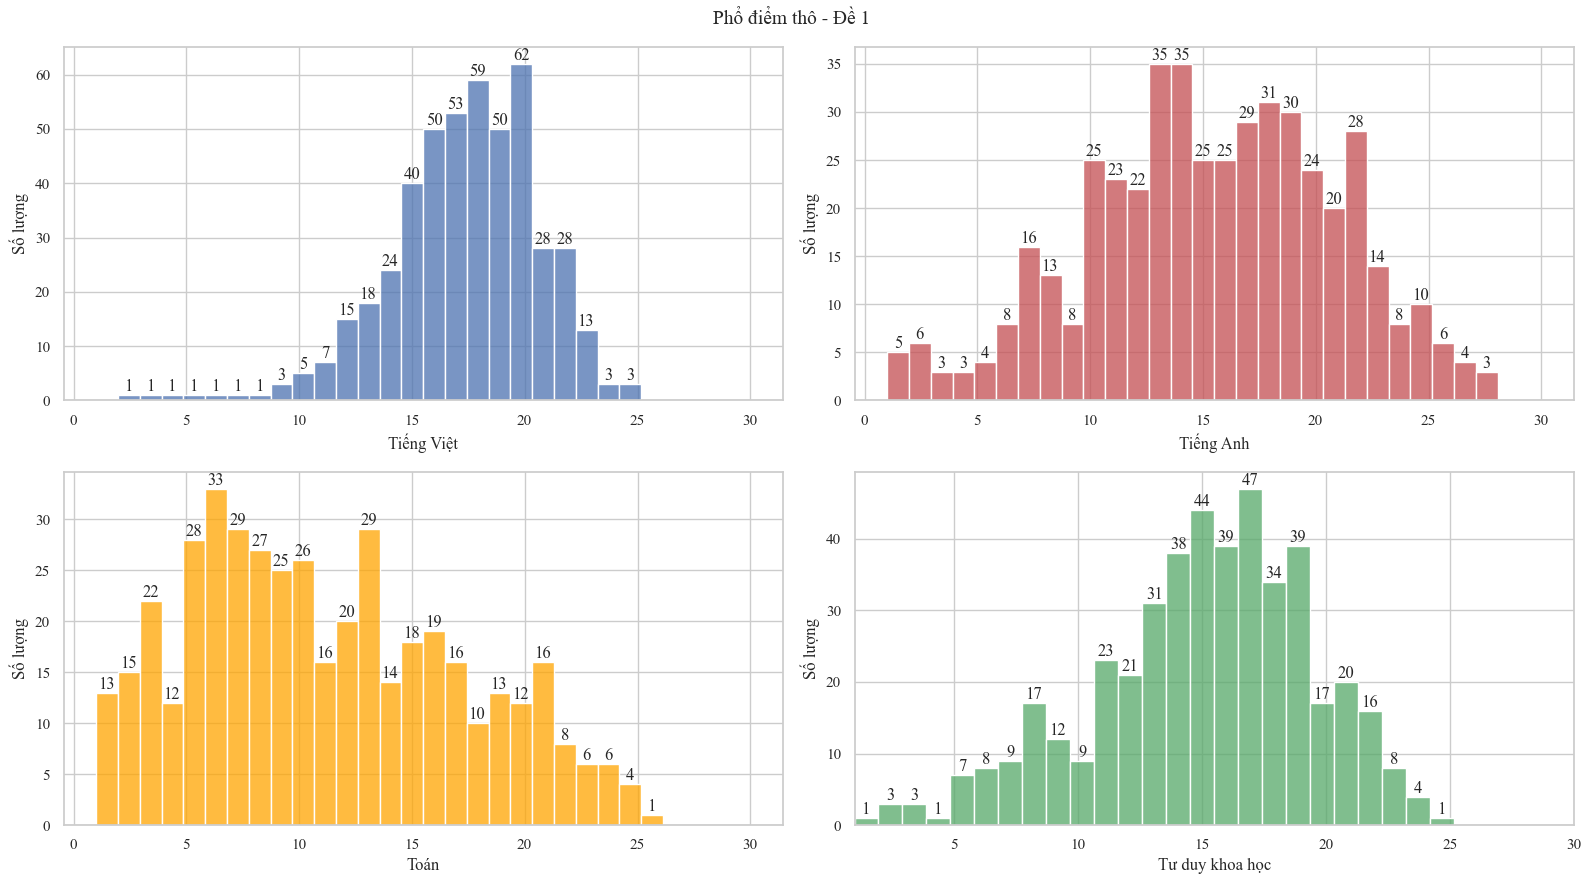

In [188]:
df_raw1 = df_TV1[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)

df_raw1 = df_raw1.merge(df_TA1[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw1 = df_raw1.merge(df_TO1[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw1 = df_raw1.merge(df_KH1[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')

ip.draw_plot(df_raw1, col_name='Raw', title='Phổ điểm thô - Đề 1', range=(1,30))

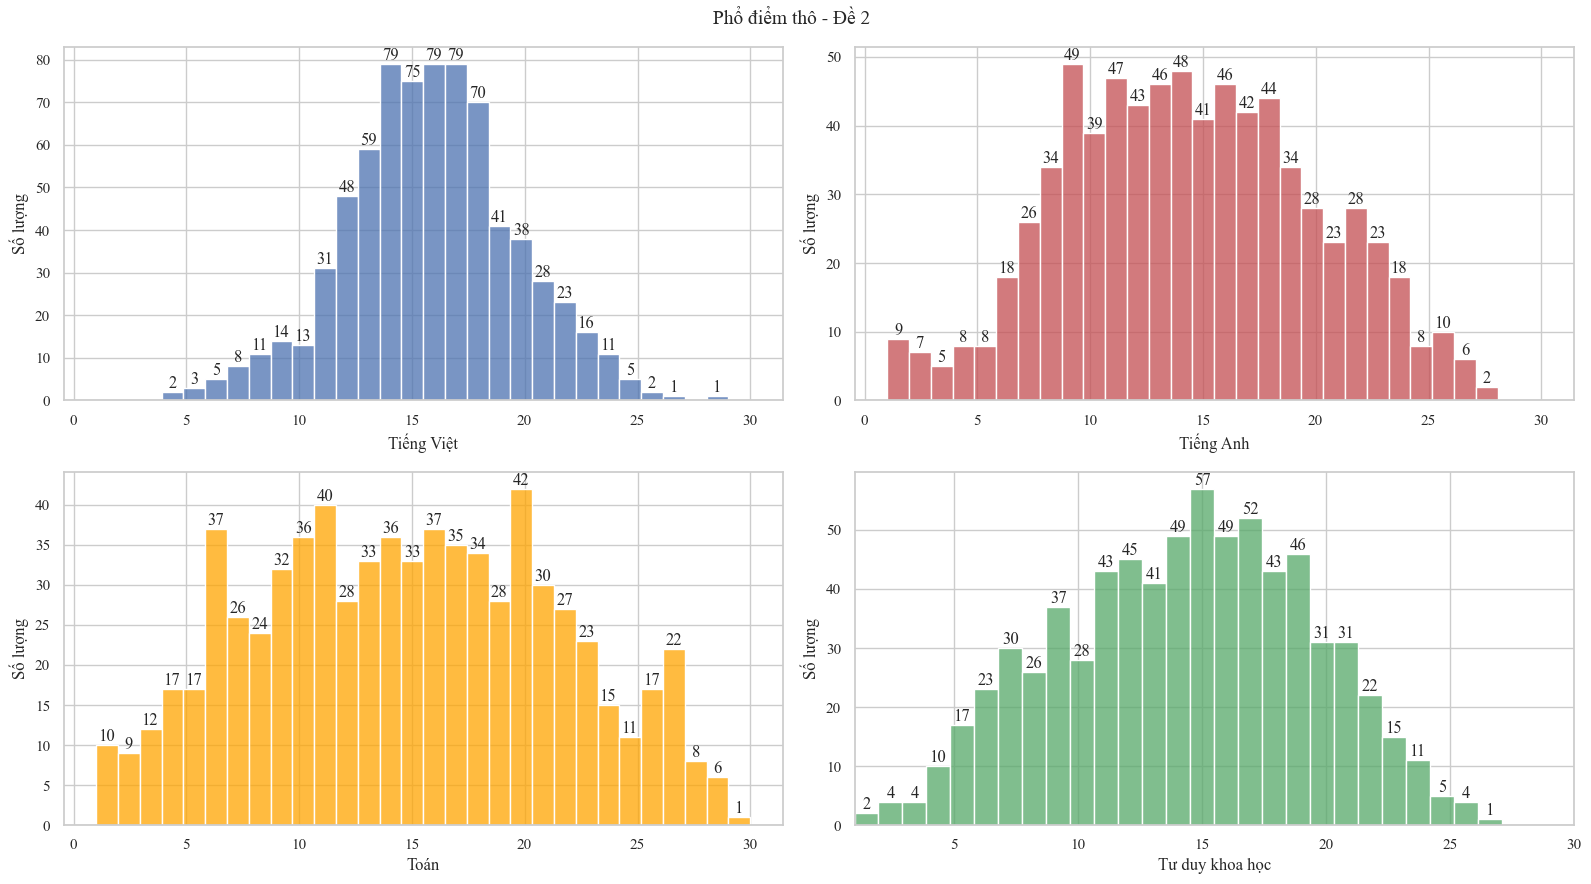

In [189]:
df_raw2 = df_TV2[['SBD', 'Raw']].copy().rename({'Raw': 'RawTV'}, axis=1)

df_raw2 = df_raw2.merge(df_TA2[['SBD', 'Raw']].rename({'Raw': 'RawTA'}, axis=1), on='SBD', how='outer')
df_raw2 = df_raw2.merge(df_TO2[['SBD', 'Raw']].rename({'Raw': 'RawTO'}, axis=1), on='SBD', how='outer')
df_raw2 = df_raw2.merge(df_KH2[['SBD', 'Raw']].rename({'Raw': 'RawKH'}, axis=1), on='SBD', how='outer')
ip.draw_plot(df_raw2, col_name='Raw', title='Phổ điểm thô - Đề 2', range=(1,30))

In [190]:
rawtotal_1 = pd.Series(df_TV1['Raw'] + df_TA1['Raw'] + df_TO1['Raw'] + df_KH1['Raw'])
rawtotal_2 = pd.Series(df_TV2['Raw'] + df_TA2['Raw'] + df_TO2['Raw'] + df_KH2['Raw'])


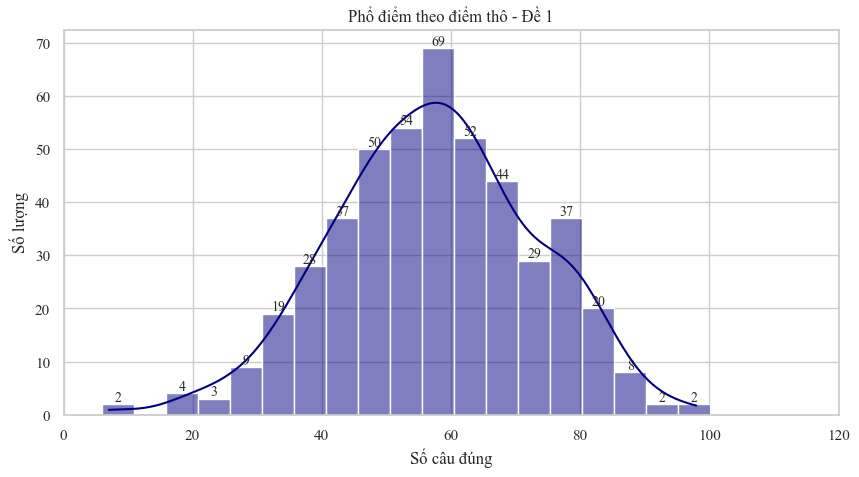

In [191]:
ip.plot_total(rawtotal_1, title='Phổ điểm theo điểm thô - Đề 1', range=(1,120), color='navy', xlabel='Số câu đúng', ylabel='Số lượng', lim=(0, 120))

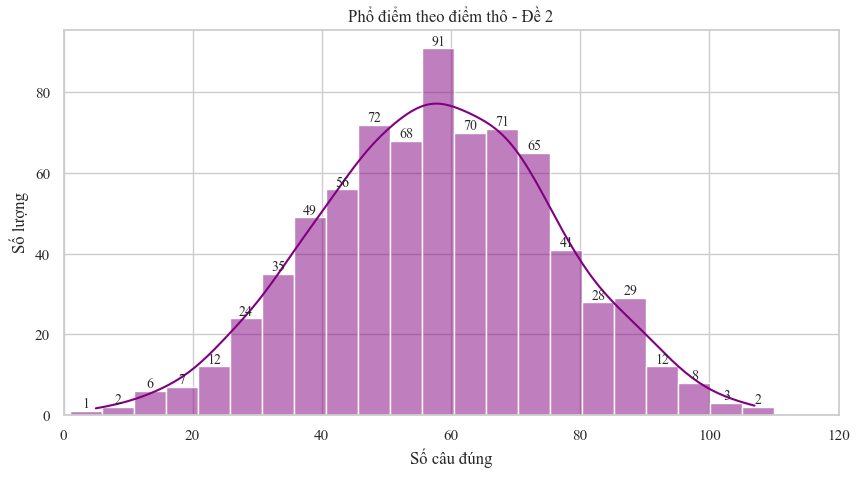

In [192]:
ip.plot_total(rawtotal_2, title='Phổ điểm theo điểm thô - Đề 2', range=(1,120), color='purple', xlabel='Số câu đúng', ylabel='Số lượng', lim=(0, 120))

In [193]:
diff_1, diff_2 =  pd.DataFrame(), pd.DataFrame()
for data in [df_TV1, df_TA1, df_TO1, df_KH1]:
    b = (ctt.cal_diff(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    diff_1 = pd.concat([diff_1, b], axis=0)

for data in [df_TV2, df_TA2, df_TO2, df_KH2]:
    b = (ctt.cal_diff(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    diff_2 = pd.concat([diff_2, b], axis=0)

diff_1 = diff_1.rename({0: 'CTT'}, axis=1)
diff_2 = diff_2.rename({0: 'CTT'}, axis=1)

In [194]:
diff_2.describe()

,CTT
count,120.000000
mean,0.492247
std,0.182863
min,0.084906
25%,0.374675
50%,0.461228
75%,0.613752
max,0.913747


In [195]:
def b_category(diff):
    if diff > 0.9:
        return 'Rất dễ'
    elif diff > 0.75:
        return 'Dễ'
    elif diff > 0.6:
        return 'Tương đối dễ'
    elif diff > 0.4:
        return 'Bình thường'
    elif diff > 0.25:
        return 'Tương đối khó'
    elif diff > 0.1:
        return 'Khó'
    else:
        return 'Rất khó'
    
diff_1['Phân loại'] = diff_1['CTT'].apply(b_category)
diff_2['Phân loại'] = diff_2['CTT'].apply(b_category)

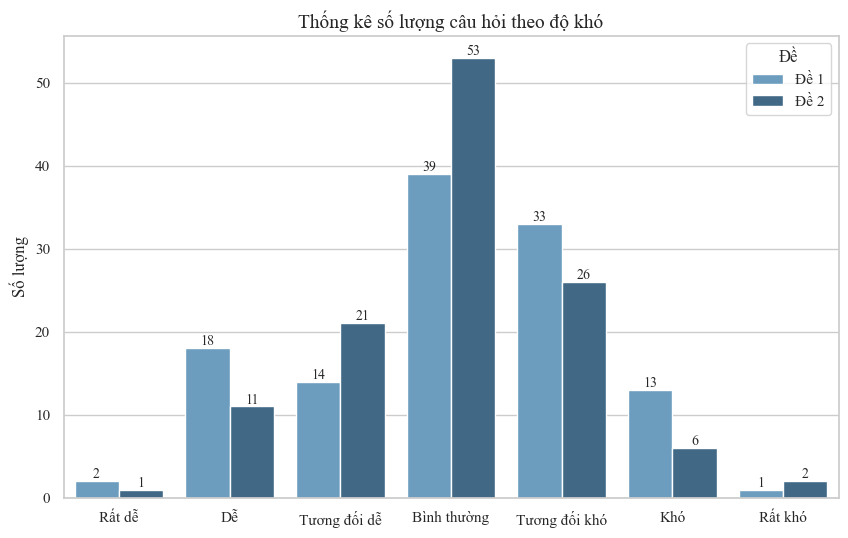

In [196]:
ip.plot_item(diff_1, diff_2, title='Thống kê số lượng câu hỏi theo độ khó', order=order_kho, palette='Blues_d', size=(10,6))

In [197]:
diff_1

,CTT,Phân loại
Cau1,0.784188,Dễ
Cau2,0.882479,Dễ
Cau3,0.831197,Dễ
Cau4,0.121795,Khó
Cau5,0.314103,Tương đối khó
...,...,...
Cau116,0.263274,Tương đối khó
Cau117,0.508850,Bình thường
Cau118,0.165929,Khó
Cau119,0.579646,Bình thường


In [198]:
diff_1['Phần thi'] = (
    diff_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

diff_2['Phần thi'] = (
    diff_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

Text(0.5, 0.98, 'Độ khó xét theo từng phần thi của mỗi đợt')

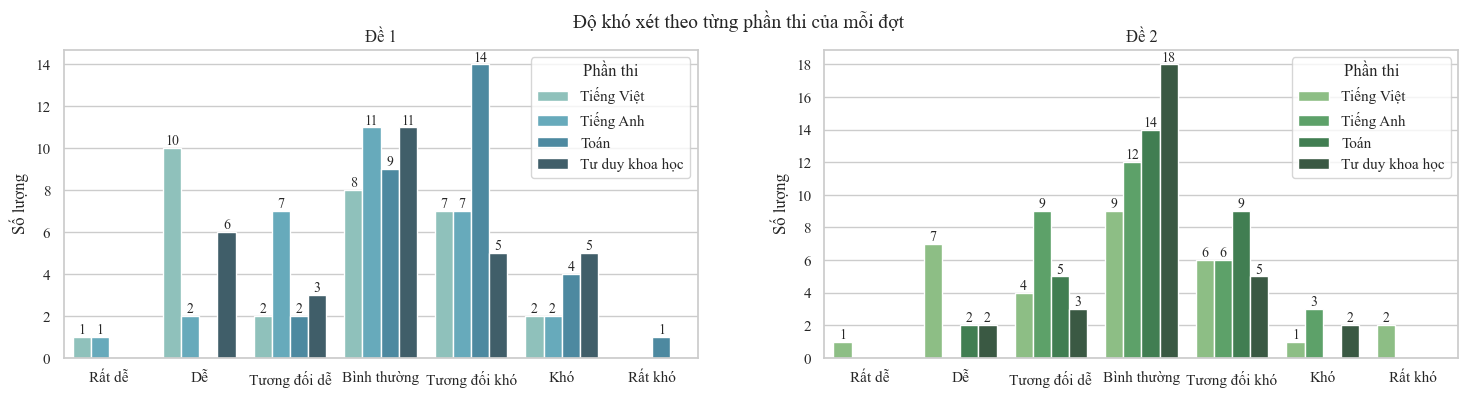

In [199]:
fig, axes = plt.subplots(ncols=2, figsize=(18, 4))
sns.countplot(data=diff_1, x='Phân loại', palette='GnBu_d', ax=axes[0], hue='Phần thi', order=order_kho)
axes[0].set_title('Đề 1')
for p in axes[0].patches:
        height = p.get_height()
        if height >0:
            axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
sns.countplot(data=diff_2, x='Phân loại', palette='YlGn_d', ax=axes[1], hue='Phần thi', order=order_kho)
axes[0].set_ylabel('Số lượng')
axes[0].set_xlabel(None)
for p in axes[1].patches:
        height = p.get_height()
        if height >0:
            axes[1].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
axes[1].set_title('Đề 2')
axes[1].set_ylabel('Số lượng')
axes[1].set_xlabel(None)

max_y1 = int(max([p.get_height() for p in axes[0].patches] or [0]))
max_y2 = int(max([p.get_height() for p in axes[1].patches] or [0]))

axes[0].set_yticks(range(0, max_y1 + 1, 2))
axes[1].set_yticks(range(0, max_y2 + 1, 2))

plt.suptitle('Độ khó xét theo từng phần thi của mỗi đợt', fontsize=14)

C:\Users\Administra\AppData\Local\Temp\ipykernel_20892\1872895512.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diff_1, x='Phần thi', y='CTT', palette='Blues_d', ax=axes[0])
C:\Users\Administra\AppData\Local\Temp\ipykernel_20892\1872895512.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=diff_2, x='Phần thi', y='CTT', palette='Purples_d', ax=axes[1])


Text(0.5, 0, '')

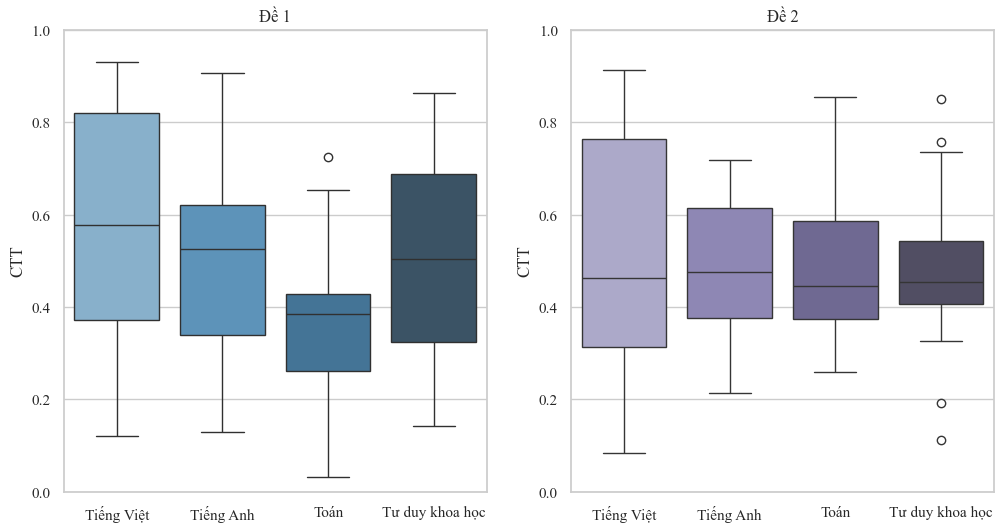

In [200]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
sns.boxplot(data=diff_1, x='Phần thi', y='CTT', palette='Blues_d', ax=axes[0])
axes[0].set_title('Đề 1')
axes[0].set_ylim(0,1)
axes[0].set_xlabel(None)
sns.boxplot(data=diff_2, x='Phần thi', y='CTT', palette='Purples_d', ax=axes[1])
axes[1].set_title('Đề 2')
axes[1].set_ylim(0,1)
axes[1].set_xlabel(None)
#plt.suptitle('Chênh lệch độ khó theo từng phần thi của mỗi đợt', fontsize=16)

In [201]:
disc_1, disc_2 =  pd.DataFrame(), pd.DataFrame()
for data in [df_TV1, df_TA1, df_TO1, df_KH1]:
    data = ip.tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    disc_1 = pd.concat([disc_1, a], axis=0)

for data in [df_TV2, df_TA2, df_TO2, df_KH2]:
    data = ip.tinh_diem(data)
    a = (ctt.cal_disc(data[data['Null'] < 30])) # loại những thí sinh không thi 1 phần (bỏ toàn bộ câu hỏi của phần thi đó)
    disc_2 = pd.concat([disc_2, a], axis=0)

disc_1 = disc_1.rename({0: 'D-Index'}, axis=1)
disc_2 = disc_2.rename({0: 'D-Index'}, axis=1)

In [202]:
def a_category(disc):
    if disc <= 0:
        return 'Kém'
    elif disc <= 0.20:
        return 'Chưa tốt'
    elif disc <= 0.40:
        return 'Chấp nhận được'
    elif disc <= 0.60:
        return 'Tương đối tốt'
    elif disc <= 0.80:
        return 'Tốt'
    elif disc <= 1.0:
        return 'Rất tốt'
    else:
        return 'Quá tốt'
    
disc_1['Phân loại'] = disc_1['D-Index'].apply(a_category)
disc_2['Phân loại'] = disc_2['D-Index'].apply(a_category)

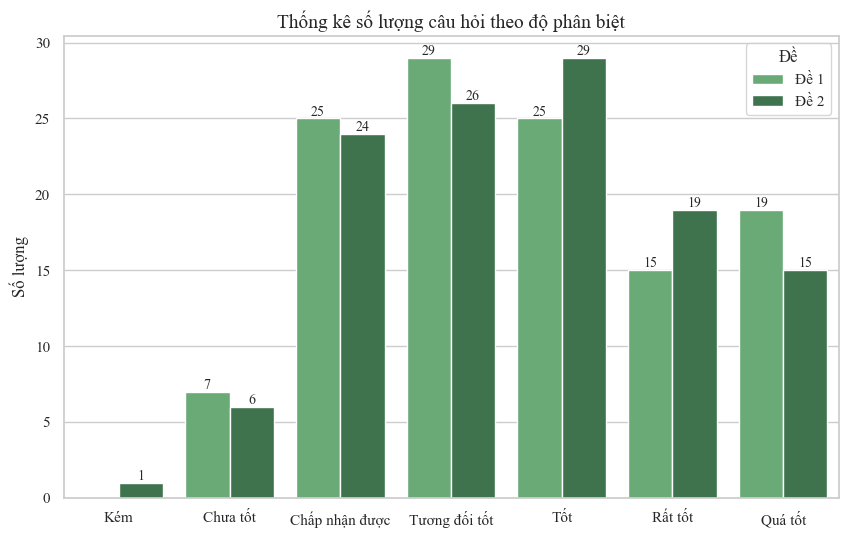

In [203]:
ip.plot_item(disc_1, disc_2, title='Thống kê số lượng câu hỏi theo độ phân biệt', order=order_pb, palette='Greens_d', size=(10,6))

In [204]:
disc_1['Phần thi'] = (
    disc_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

disc_2['Phần thi'] = (
    disc_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

Text(0.5, 0.98, 'Độ phân biệt xét theo từng phần thi của mỗi đợt')

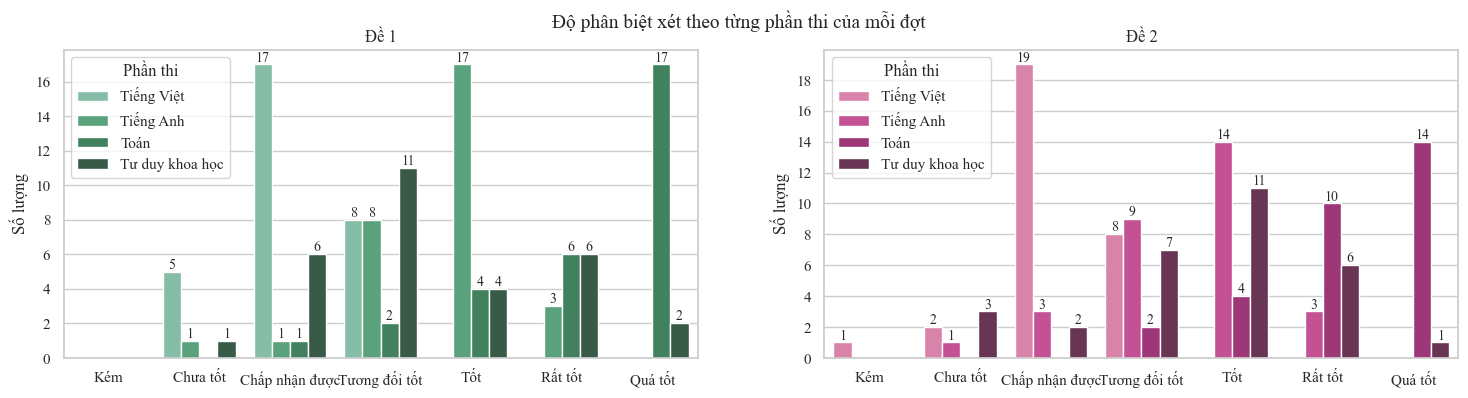

In [205]:
fig, axes = plt.subplots(ncols=2, figsize=(18, 4))
sns.countplot(data=disc_1, x='Phân loại', palette='BuGn_d', ax=axes[0], hue='Phần thi', order=order_pb)
axes[0].set_title('Đề 1')
for p in axes[0].patches:
        height = p.get_height()
        if height >0:
            axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
sns.countplot(data=disc_2, x='Phân loại', palette='RdPu_d', ax=axes[1], hue='Phần thi', order=order_pb)
axes[0].set_ylabel('Số lượng')
axes[0].set_xlabel(None)
for p in axes[1].patches:
        height = p.get_height()
        if height >0:
            axes[1].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
axes[1].set_title('Đề 2')
axes[1].set_ylabel('Số lượng')
axes[1].set_xlabel(None)

max_y1 = int(max([p.get_height() for p in axes[0].patches] or [0]))
max_y2 = int(max([p.get_height() for p in axes[1].patches] or [0]))

axes[0].set_yticks(range(0, max_y1 + 1, 2))
axes[1].set_yticks(range(0, max_y2 + 1, 2))

plt.suptitle('Độ phân biệt xét theo từng phần thi của mỗi đợt', fontsize=14)

C:\Users\Administra\AppData\Local\Temp\ipykernel_20892\799261752.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=disc_1, x='Phần thi', y='D-Index', palette='viridis_d', ax=axes[0])
C:\Users\Administra\AppData\Local\Temp\ipykernel_20892\799261752.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=disc_2, x='Phần thi', y='D-Index', palette='plasma_d', ax=axes[1])


Text(0.5, 0, '')

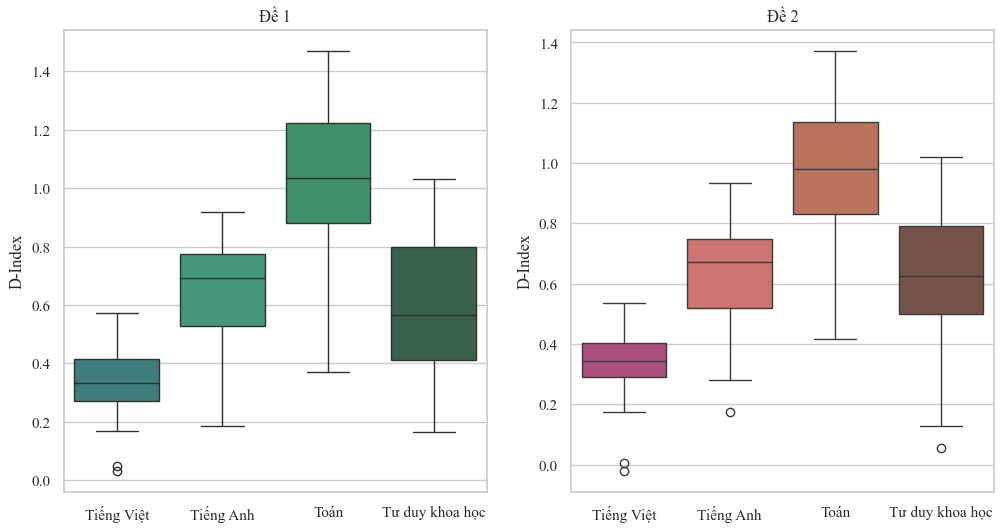

In [206]:
fig, axes = plt.subplots(ncols=2, figsize=(12, 6))
sns.boxplot(data=disc_1, x='Phần thi', y='D-Index', palette='viridis_d', ax=axes[0])
axes[0].set_title('Đề 1')
axes[0].set_xlabel(None)
sns.boxplot(data=disc_2, x='Phần thi', y='D-Index', palette='plasma_d', ax=axes[1])
axes[1].set_title('Đề 2')
axes[1].set_xlabel(None)
#plt.suptitle('Chênh lệch độ phân biệt theo từng phần thi của mỗi đợt', fontsize=16)

In [209]:
def do_nhieu(data: pd.DataFrame, chamdiem, answer: pd.DataFrame, start, end):
    # Merge 1 lần
    data = data.merge(chamdiem[['SBD', 'Raw', 'Null']], on='SBD', how='left')
    ans_row = answer.iloc[0]

    # DataFrame lưu kết quả tổng hợp
    df_all = pd.DataFrame(columns=["A", "B", "C", "D", "Null", "Ans"])

    # Lọc thí sinh hợp lệ
    valid = data[data['Null'] < 30]

    for stt in range(start, end + 1):
        std = valid['Raw'].std()
        cau_col = f"Cau{stt}"
        correct = ans_row[cau_col]
        n_total = valid.shape[0]
        pbcc_dict = {}

        for opt in ["A", "B", "C", "D"]:

            true_group  = valid.loc[valid[cau_col] == opt, 'Raw']
            false_group = valid.loc[valid[cau_col] != opt, 'Raw']
            if true_group.shape[0] == 0 or false_group.shape[0] == 0:
                pb = np.nan
            else:
                p = true_group.shape[0] / valid[cau_col].shape[0]
                pb = ctt.cal_pbcc(true_group, false_group, std, p)

            pbcc_dict[opt] = pb

        true_group = valid.loc[valid[cau_col].isna(), 'Raw']
        false_group = valid.loc[valid[cau_col].notna(), 'Raw']
        count = true_group.shape[0]
        percent = count / n_total if n_total > 0 else 0
        pbcc_dict["Null"] = ctt.cal_pbcc(true_group, false_group, std, percent) if count > 0 and false_group.shape[0] > 0 else np.nan
        # PBCC của đáp án đúng
        pbcc_ans = pbcc_dict.get(correct, np.nan)

        # Append 1 dòng vào df_all
        df_all.loc[f'Cau{stt}'] = [
            pbcc_dict["A"],
            pbcc_dict["B"],
            pbcc_dict["C"],
            pbcc_dict["D"],
            pbcc_dict["Null"],
            pbcc_ans
        ]

    return df_all


In [210]:
nhieu_1 = pd.concat([do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TV1, start=1, end=30),
                     do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TA1, start=31, end=60),
                    do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_TO1, start=61, end=90),
                    do_nhieu(data=df_dot1, answer=da_1, chamdiem=df_KH1, start=91, end=120),], axis=0)

In [211]:
nhieu_1

,A,B,C,D,Null,Ans
Cau1,-0.090698,-0.077724,0.145350,-0.050370,-0.155385,0.145350
Cau2,-0.077654,-0.164355,0.200580,-0.258847,-0.245800,0.200580
Cau3,0.023497,0.010622,0.020272,-0.064765,-0.040957,0.010622
Cau4,0.098663,0.055808,-0.015382,-0.074254,-0.445046,0.055808
Cau5,-0.137573,0.120029,-0.081774,0.114395,-0.386559,0.120029
...,...,...,...,...,...,...
Cau116,0.093254,0.231577,0.015300,0.069040,-0.411157,0.231577
Cau117,-0.146751,-0.147345,-0.014308,0.505123,-0.459603,0.505123
Cau118,-0.185613,-0.029800,0.259071,0.210703,-0.431992,0.210703
Cau119,-0.087406,0.508710,-0.103076,-0.149028,-0.440130,0.508710


In [212]:
nhieu_2 = pd.concat([
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TV2, start=1, end=30),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TA2, start=31, end=60),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_TO2, start=61, end=90),
    do_nhieu(data=df_dot2, answer=da_2, chamdiem=df_KH2, start=91, end=120),
], axis=0)


In [213]:
nhieu_2

,A,B,C,D,Null,Ans
Cau1,-0.112050,-0.119164,-0.238992,0.372054,-0.082196,0.372054
Cau2,-0.181301,-0.227150,-0.068436,0.315619,0.167767,0.315619
Cau3,-0.072206,-0.204496,0.255094,-0.106073,-0.032604,0.255094
Cau4,0.265416,-0.013612,-0.107189,-0.129261,0.207271,0.265416
Cau5,-0.039716,-0.208780,-0.179729,0.298750,-0.146674,0.298750
...,...,...,...,...,...,...
Cau116,-0.110480,0.402168,-0.213573,-0.098925,-0.259562,0.402168
Cau117,-0.198114,-0.057453,-0.174101,0.376236,-0.259836,0.376236
Cau118,-0.124422,-0.235191,-0.159096,0.557978,-0.381730,0.557978
Cau119,0.519316,-0.120816,-0.161446,-0.078337,-0.375110,0.519316


In [214]:
# hàm phân loại độ nhiễu câu hỏi
def label_distract(data):
    scale = 0
    for col in data.drop(columns='Ans').index:  # bỏ qua cột đáp án đúng
        if data[col] == data['Ans']:
            continue
        else:
            scale += (data[col]<0)
    if scale == 4:
        return "Tốt"
    elif scale == 3:
        return "Bình thường"
    elif scale == 2:
        return "Yếu"
    else:  
        return "Kém"

In [215]:
nhieu_1['Phân loại'] = nhieu_1.apply(label_distract, axis=1)
nhieu_1

,A,B,C,D,Null,Ans,Phân loại
Cau1,-0.090698,-0.077724,0.145350,-0.050370,-0.155385,0.145350,Tốt
Cau2,-0.077654,-0.164355,0.200580,-0.258847,-0.245800,0.200580,Tốt
Cau3,0.023497,0.010622,0.020272,-0.064765,-0.040957,0.010622,Yếu
Cau4,0.098663,0.055808,-0.015382,-0.074254,-0.445046,0.055808,Bình thường
Cau5,-0.137573,0.120029,-0.081774,0.114395,-0.386559,0.120029,Bình thường
...,...,...,...,...,...,...,...
Cau116,0.093254,0.231577,0.015300,0.069040,-0.411157,0.231577,Kém
Cau117,-0.146751,-0.147345,-0.014308,0.505123,-0.459603,0.505123,Tốt
Cau118,-0.185613,-0.029800,0.259071,0.210703,-0.431992,0.210703,Bình thường
Cau119,-0.087406,0.508710,-0.103076,-0.149028,-0.440130,0.508710,Tốt


In [216]:
nhieu_2['Phân loại'] = nhieu_2.apply(label_distract, axis=1)
nhieu_2

,A,B,C,D,Null,Ans,Phân loại
Cau1,-0.112050,-0.119164,-0.238992,0.372054,-0.082196,0.372054,Tốt
Cau2,-0.181301,-0.227150,-0.068436,0.315619,0.167767,0.315619,Bình thường
Cau3,-0.072206,-0.204496,0.255094,-0.106073,-0.032604,0.255094,Tốt
Cau4,0.265416,-0.013612,-0.107189,-0.129261,0.207271,0.265416,Bình thường
Cau5,-0.039716,-0.208780,-0.179729,0.298750,-0.146674,0.298750,Tốt
...,...,...,...,...,...,...,...
Cau116,-0.110480,0.402168,-0.213573,-0.098925,-0.259562,0.402168,Tốt
Cau117,-0.198114,-0.057453,-0.174101,0.376236,-0.259836,0.376236,Tốt
Cau118,-0.124422,-0.235191,-0.159096,0.557978,-0.381730,0.557978,Tốt
Cau119,0.519316,-0.120816,-0.161446,-0.078337,-0.375110,0.519316,Tốt


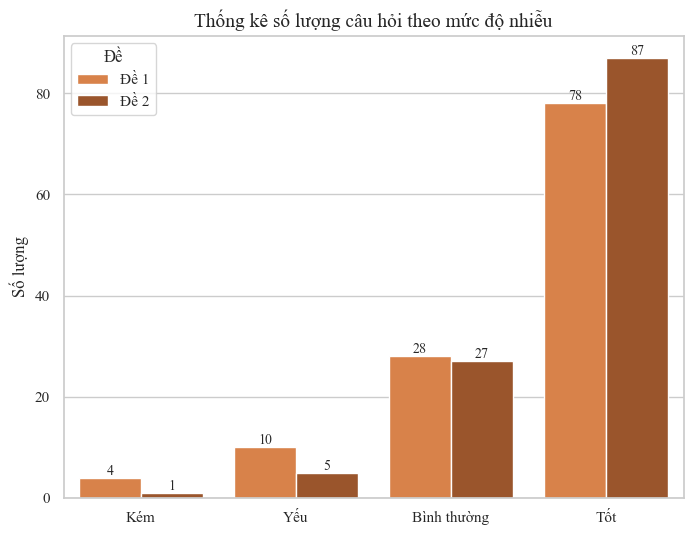

In [217]:
ip.plot_item(nhieu_1, nhieu_2, title='Thống kê số lượng câu hỏi theo mức độ nhiễu', order=order_nhieu, palette='Oranges_d', size=(8,6))

In [218]:
nhieu_1['Phần thi'] = (
    nhieu_1.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

nhieu_2['Phần thi'] = (
    nhieu_2.index.str.extract(r'(\d+)', expand=False)
            .astype(int)
            .map(lambda x: "Tiếng Việt" if x<=30 else
                           "Tiếng Anh" if x<=60 else
                           "Toán" if x<=90 else
                           "Tư duy khoa học")
)

Text(0.5, 0.98, 'Độ nhiễu xét theo từng phần thi của mỗi đợt')

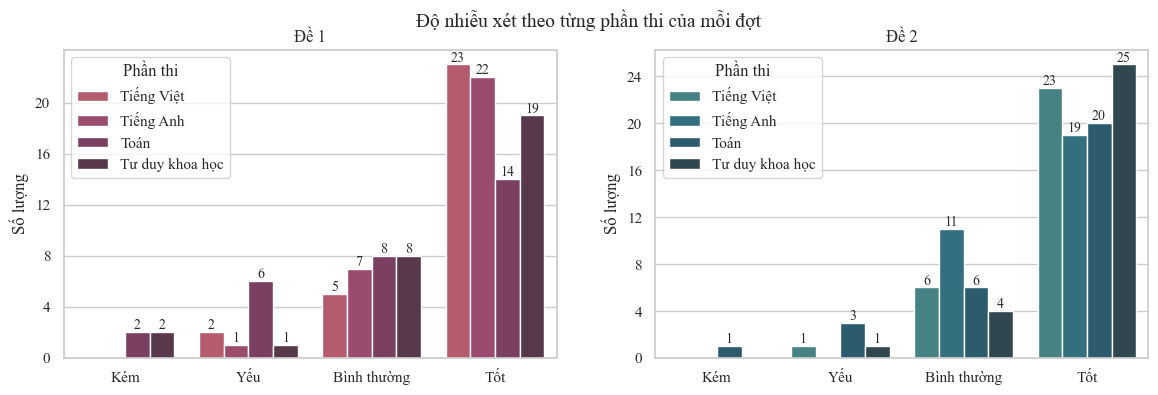

In [219]:
fig, axes = plt.subplots(ncols=2, figsize=(14, 4))
sns.countplot(data=nhieu_1, x='Phân loại', palette='flare_d', ax=axes[0], hue='Phần thi', order=order_nhieu)
axes[0].set_title('Đề 1')
for p in axes[0].patches:
        height = p.get_height()
        if height >0:
            axes[0].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
sns.countplot(data=nhieu_2, x='Phân loại', palette='crest_d', ax=axes[1], hue='Phần thi', order=order_nhieu)
axes[0].set_ylabel('Số lượng')
axes[0].set_xlabel(None)
for p in axes[1].patches:
        height = p.get_height()
        if height >0:
            axes[1].annotate(f'{int(height)}', (p.get_x() + p.get_width() / 2, height),
                            ha='center', va='bottom', fontsize=10)
axes[1].set_title('Đề 2')
axes[1].set_ylabel('Số lượng')
axes[1].set_xlabel(None)

max_y1 = int(max([p.get_height() for p in axes[0].patches] or [0]))
max_y2 = int(max([p.get_height() for p in axes[1].patches] or [0]))

axes[0].set_yticks(range(0, max_y1 + 1, 4))
axes[1].set_yticks(range(0, max_y2 + 1, 4))

plt.suptitle('Độ nhiễu xét theo từng phần thi của mỗi đợt', fontsize=14)

In [ ]:
diff_1['CTT']

Cau1      0.784188
Cau2      0.882479
Cau3      0.831197
Cau4      0.121795
Cau5      0.314103
            ...   
Cau116    0.263274
Cau117    0.508850
Cau118    0.165929
Cau119    0.579646
Cau120    0.422566
Name: CTT, Length: 120, dtype: float64

In [220]:
item_ctt_1 = pd.concat([
    diff_1.rename(columns={'Phân loại': 'Độ khó'}).drop(columns='Phần thi'),
    disc_1.rename(columns={'Phân loại': 'Độ phân biệt'}).drop(columns='Phần thi'),
    nhieu_1.rename(columns={'Phân loại': 'Độ nhiễu'}).drop(columns='Phần thi')
], axis=1)

item_ctt_2 = pd.concat([
    diff_2.rename(columns={'Phân loại': 'Độ khó'}).drop(columns='Phần thi'),
    disc_2.rename(columns={'Phân loại': 'Độ phân biệt'}).drop(columns='Phần thi'),
    nhieu_2.rename(columns={'Phân loại': 'Độ nhiễu'}).drop(columns='Phần thi')
], axis=1)

In [221]:
item_ctt_1, item_ctt_2

(             CTT         Độ khó   D-Index   Độ phân biệt         A         B  \
 Cau1    0.784188             Dễ  0.174603       Chưa tốt -0.090698 -0.077724   
 Cau2    0.882479             Dễ  0.182540       Chưa tốt -0.077654 -0.164355   
 Cau3    0.831197             Dễ  0.031746       Chưa tốt  0.023497  0.010622   
 Cau4    0.121795            Khó  0.047619       Chưa tốt  0.098663  0.055808   
 Cau5    0.314103  Tương đối khó  0.166667       Chưa tốt -0.137573  0.120029   
 ...          ...            ...       ...            ...       ...       ...   
 Cau116  0.263274  Tương đối khó  0.590164  Tương đối tốt  0.093254  0.231577   
 Cau117  0.508850    Bình thường  1.032787        Quá tốt -0.146751 -0.147345   
 Cau118  0.165929            Khó  0.557377  Tương đối tốt -0.185613 -0.029800   
 Cau119  0.579646    Bình thường  0.975410        Rất tốt -0.087406  0.508710   
 Cau120  0.422566    Bình thường  0.885246        Rất tốt -0.105607  0.394653   
 
                C         

In [222]:
import textwrap

def wrap_labels(ax, width=10):
    ax.set_xticklabels(
        ["\n".join(textwrap.wrap(t.get_text(), width)) for t in ax.get_xticklabels()]
    )
    ax.set_yticklabels(
        ["\n".join(textwrap.wrap(t.get_text(), width)) for t in ax.get_yticklabels()]
    )
    
def heatmap_pair(df, col1, col2, title, cmap, order1=None, order2=None, ax=None):
    if order1 is not None:
        df[col1] = pd.Categorical(df[col1], categories=order1, ordered=True)
    if order2 is not None:
        df[col2] = pd.Categorical(df[col2], categories=order2, ordered=True)

    ct = pd.crosstab(df[col1], df[col2])

    #plt.figure(figsize=(6, 6))
    ax = sns.heatmap(ct, annot=True, fmt="d", cmap=cmap, cbar=False, ax=ax)

    ax.set_title(title)
    plt.xlabel(col2)
    plt.ylabel(col1)

    ax.set_xticklabels(ax.get_xticklabels(), rotation=0) 
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    # Tự động xuống dòng
    wrap_labels(ax, width=8)

    plt.tight_layout()

Text(0.5, 1.02, 'Ma trận tương quan giữa các chỉ số CTT - Đề 1')

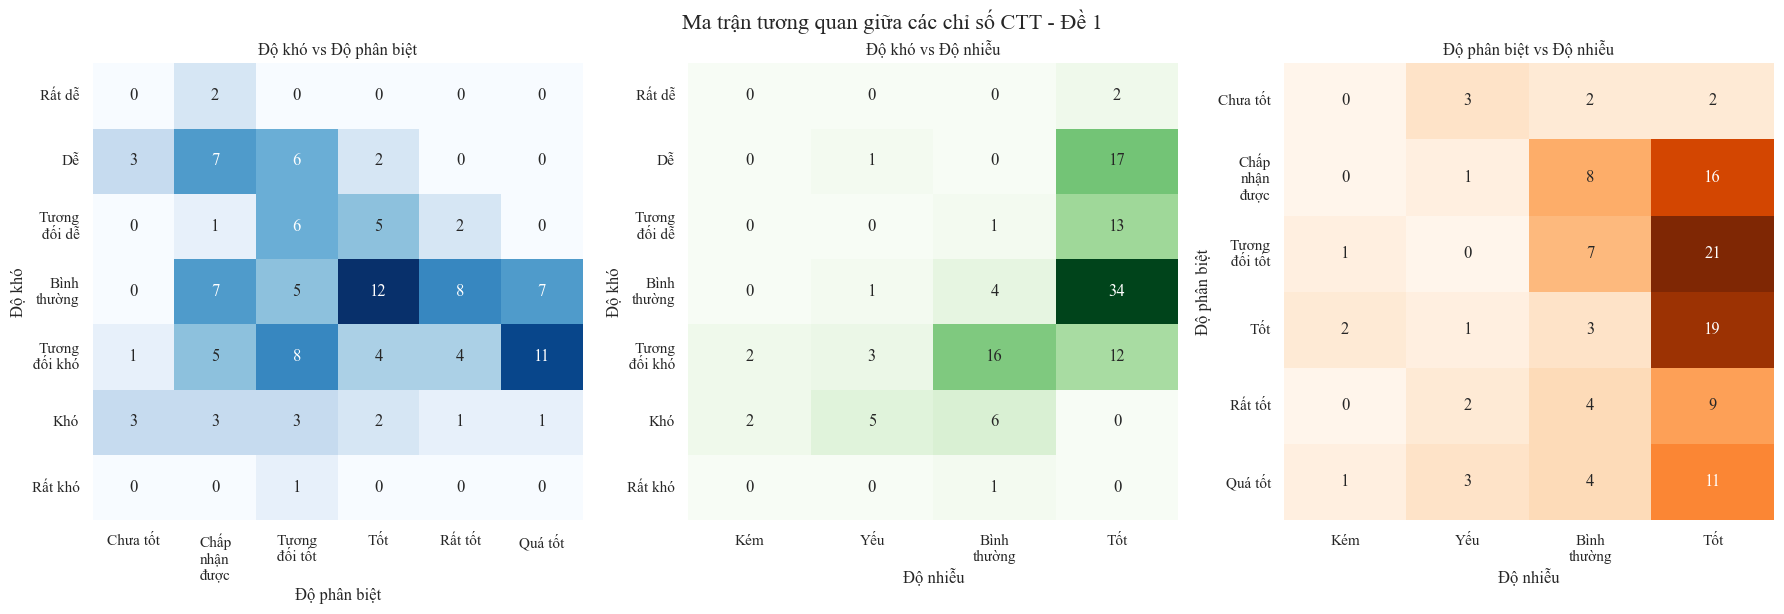

In [223]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
heatmap_pair(item_ctt_1, "Độ khó", "Độ phân biệt",
             "Độ khó vs Độ phân biệt", cmap="Blues",
             order1=order_kho,
             order2=order_pb, ax=axes[0])

heatmap_pair(item_ctt_1, "Độ khó", "Độ nhiễu",
             "Độ khó vs Độ nhiễu", cmap="Greens",
             order1=order_kho,
             order2=order_nhieu, ax=axes[1])

heatmap_pair(item_ctt_1, "Độ phân biệt", "Độ nhiễu",
             "Độ phân biệt vs Độ nhiễu", cmap="Oranges",
             order1=order_pb,
             order2=order_nhieu, ax=axes[2])

plt.suptitle('Ma trận tương quan giữa các chỉ số CTT - Đề 1', fontsize=16, y=1.02)

Text(0.5, 1.02, 'Ma trận tương quan giữa các chỉ số CTT - Đề 2')

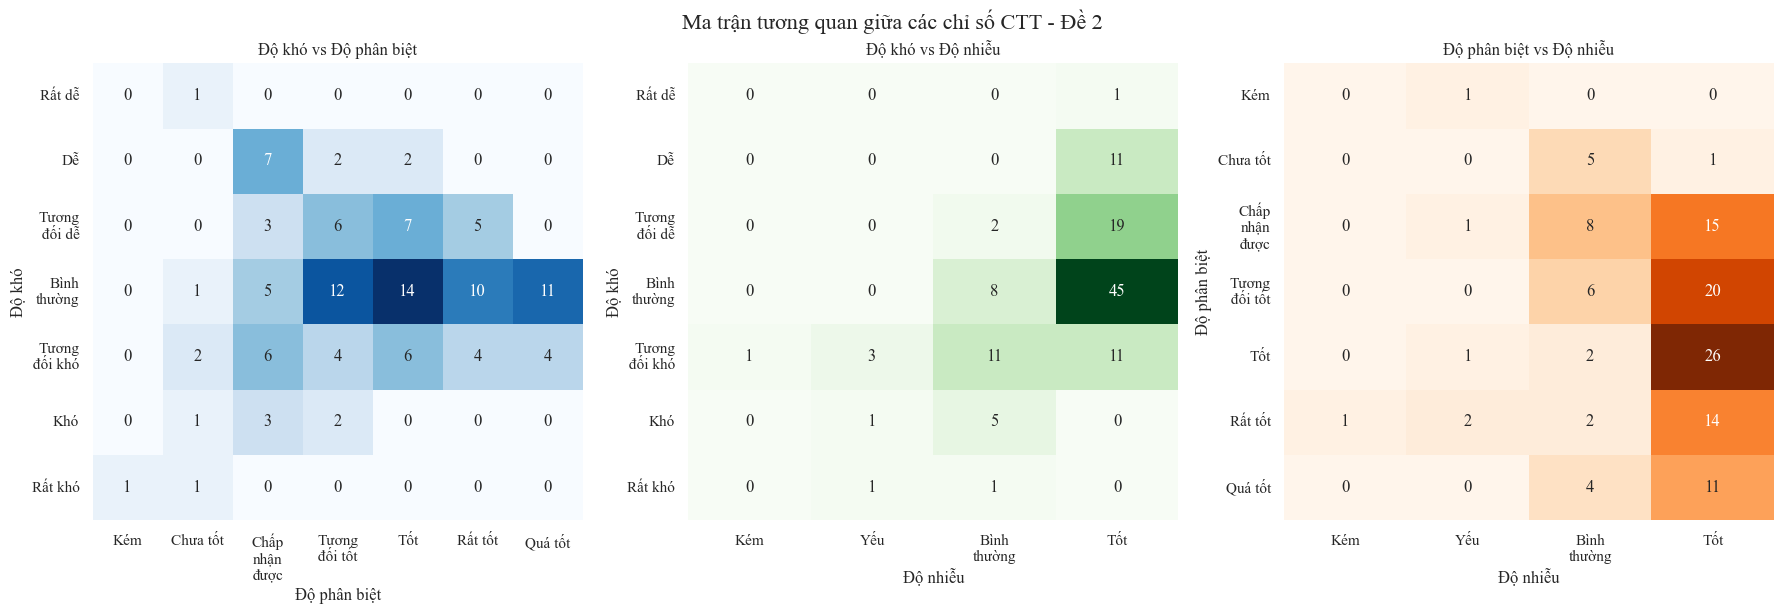

In [224]:
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))
heatmap_pair(item_ctt_2, "Độ khó", "Độ phân biệt",
             "Độ khó vs Độ phân biệt", cmap="Blues",
             order1=order_kho,
             order2=order_pb, ax=axes[0])

heatmap_pair(item_ctt_2, "Độ khó", "Độ nhiễu",
             "Độ khó vs Độ nhiễu", cmap="Greens",
             order1=order_kho,
             order2=order_nhieu, ax=axes[1])

heatmap_pair(item_ctt_2, "Độ phân biệt", "Độ nhiễu",
             "Độ phân biệt vs Độ nhiễu", cmap="Oranges",
             order1=order_pb,
             order2=order_nhieu, ax=axes[2])

plt.suptitle('Ma trận tương quan giữa các chỉ số CTT - Đề 2', fontsize=16, y=1.02)

In [ ]:
a_init_1 = nhieu_1['Ans'].apply(irt.cal_disc)
a_init_2 = nhieu_2['Ans'].apply(irt.cal_disc)
b_init_1 = diff_1['CTT'].apply(irt.cal_diff)
b_init_2 = diff_2['CTT'].apply(irt.cal_diff)

In [ ]:
b_init_1.iloc[:30]

Cau1    -1.290241
Cau2    -2.016114
Cau3    -1.594131
Cau4     1.975542
Cau5     0.781009
Cau6    -1.563976
Cau7     1.087249
Cau8     0.197218
Cau9    -0.354081
Cau10   -1.367702
Cau11    0.136966
Cau12   -0.042742
Cau13   -1.534403
Cau14    0.371744
Cau15   -1.789269
Cau16    0.955511
Cau17   -0.389465
Cau18    0.635989
Cau19   -0.275229
Cau20   -0.434038
Cau21   -0.240468
Cau22    0.617161
Cau23    0.533684
Cau24   -0.882137
Cau25   -1.448900
Cau26    0.488097
Cau27   -1.936178
Cau28   -2.578838
Cau29   -1.824549
Cau30    1.110041
Name: CTT, dtype: float64

In [ ]:
def run_irt_series(series_list, a_init_all, b_init_all):
    a_est_all, b_est_all = [], []

    for df_original, end_idx in series_list:

        df = df_original.copy()
        valid_mask = (df["Raw"] > 0) & (df["Raw"] < 30)

        # Chỉ lấy dữ liệu hợp lệ để chạy IRT (bỏ qua các trường hợp đúng/sai hết)
        df_valid = df[valid_mask]
        U = df_valid.drop(columns=['SBD', 'MaDe', 'Gioi', 'Raw', 'Null']).to_numpy()
        print( df_valid.drop(columns=['SBD', 'MaDe', 'Gioi', 'Raw', 'Null']).columns)

        a_init = a_init_all.iloc[end_idx-30:end_idx]
        b_init = b_init_all.iloc[end_idx-30:end_idx]

        # MMLE
        a_est, b_est = irt.mmle(U=U, a_init=a_init, b_init=b_init)

        # Tính theta cho dữ liệu hợp lệ
        item_params = list(zip(a_est, b_est))
        theta_valid = irt.theta_estimate(U, item_params=item_params)

        # Tạo mảng theta cuối cùng cho toàn bộ học sinh
        theta = np.empty(len(df))

        # Gán theta tính bằng IRT cho nhóm hợp lệ
        theta[valid_mask.to_numpy()] = theta_valid

        # các trường hợp đúng hoặc sai hết
        theta[df["Raw"] == 0] = -6
        theta[df["Raw"] == 30] = 6

        # Gán theta vào DataFrame
        series_list["Theta"] = theta

        a_est_all.extend(a_est)
        b_est_all.extend(b_est)

    return a_est_all, b_est_all


# --- Chạy cho bộ đề 1 ---
series_1 = [[df_TV1, 30], [df_TA1, 60], [df_TO1, 90], [df_KH1, 120]]
a_est_1, b_est_1 = run_irt_series(series_1, a_init_1, b_init_1)

# --- Chạy cho bộ đề 2 ---
series_2 = [[df_TV2, 30], [df_TA2, 60], [df_TO2, 90], [df_KH2, 120]]
a_est_2, b_est_2 = run_irt_series(series_2, a_init_2, b_init_2)


Index(['Cau1', 'Cau2', 'Cau3', 'Cau4', 'Cau5', 'Cau6', 'Cau7', 'Cau8', 'Cau9',
       'Cau10', 'Cau11', 'Cau12', 'Cau13', 'Cau14', 'Cau15', 'Cau16', 'Cau17',
       'Cau18', 'Cau19', 'Cau20', 'Cau21', 'Cau22', 'Cau23', 'Cau24', 'Cau25',
       'Cau26', 'Cau27', 'Cau28', 'Cau29', 'Cau30'],
      dtype='object')
Start MMLE: N=468, J=30, K=81
Index(['Cau31', 'Cau32', 'Cau33', 'Cau34', 'Cau35', 'Cau36', 'Cau37', 'Cau38',
       'Cau39', 'Cau40', 'Cau41', 'Cau42', 'Cau43', 'Cau44', 'Cau45', 'Cau46',
       'Cau47', 'Cau48', 'Cau49', 'Cau50', 'Cau51', 'Cau52', 'Cau53', 'Cau54',
       'Cau55', 'Cau56', 'Cau57', 'Cau58', 'Cau59', 'Cau60'],
      dtype='object')
Start MMLE: N=463, J=30, K=81
Index(['Cau61', 'Cau62', 'Cau63', 'Cau64', 'Cau65', 'Cau66', 'Cau67', 'Cau68',
       'Cau69', 'Cau70', 'Cau71', 'Cau72', 'Cau73', 'Cau74', 'Cau75', 'Cau76',
       'Cau77', 'Cau78', 'Cau79', 'Cau80', 'Cau81', 'Cau82', 'Cau83', 'Cau84',
       'Cau85', 'Cau86', 'Cau87', 'Cau88', 'Cau89', 'Cau90'],
      dt

In [ ]:
a_est_1[90:120]

[0.7110897532808246,
 0.5168017595078251,
 0.34776382021400304,
 1.0524281690526662,
 0.37287736066286564,
 0.533322567553911,
 0.7070160290422284,
 0.3681283164306622,
 0.35869171456691373,
 0.6055873988302297,
 0.483070209086912,
 0.09905664602453432,
 0.2544478461174445,
 0.4344092862436551,
 0.48975653305802436,
 0.3954752822737068,
 0.21368974375583505,
 0.8250226852044078,
 0.5137816743901302,
 0.5935161350422681,
 0.06429681388667151,
 0.3690138187264852,
 0.9954360893168047,
 0.27491338734555304,
 0.4637459056674577,
 0.2130848903801514,
 0.7536057541486095,
 0.43028875396050337,
 0.6470935467774185,
 0.43433158420625617]

In [ ]:
df_TV1

,SBD,MaDe,Gioi,Cau1,Cau2,Cau3,Cau4,Cau5,Cau6,Cau7,...,Cau23,Cau24,Cau25,Cau26,Cau27,Cau28,Cau29,Cau30,Raw,Null
0,110001,107,Nam,1,1,0,1,0,1,0,...,0,1,1,1,1,1,1,0,21,1
1,110002,107,Nữ,1,1,1,0,-1,-1,1,...,0,1,1,1,-1,1,1,0,16,4
2,110003,107,Nam,0,1,1,0,0,1,0,...,1,1,1,1,1,1,1,0,19,0
3,110004,107,Nữ,0,1,1,0,0,1,0,...,0,1,1,1,1,1,1,1,16,0
4,110005,107,Nam,1,1,1,0,1,1,0,...,1,0,1,0,1,1,1,1,20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
471,110472,107,Nữ,1,1,1,1,1,1,1,...,0,0,1,1,1,1,1,0,20,0
472,110473,107,Nữ,1,1,1,0,0,1,1,...,1,1,1,0,1,1,1,0,20,0
473,110474,107,Nữ,1,1,1,0,0,0,0,...,1,0,1,1,0,1,0,0,15,0
474,110475,107,Nữ,1,1,1,1,0,1,1,...,1,0,1,0,1,1,1,0,15,0
